In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'WenQuanYi Zen Hei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

In [2]:
os.getcwd()

'D:\\Python_set\\Python_code\\4_InteractionMARL-Coop-main\\OnlineRetailProject\\purePythonProject\\notebooks'

In [3]:
df = pd.read_csv('../../data/raw/online_retail_two/online_retail_II.csv')

In [4]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


In [6]:
df.describe()

,Quantity,Price,Customer ID
count,1.067371e+06,1.067371e+06,824364.000000
mean,9.938898e+00,4.649388e+00,15324.638504
std,1.727058e+02,1.235531e+02,1697.464450
min,-8.099500e+04,-5.359436e+04,12346.000000
25%,1.000000e+00,1.250000e+00,13975.000000
50%,3.000000e+00,2.100000e+00,15255.000000
75%,1.000000e+01,4.150000e+00,16797.000000
max,8.099500e+04,3.897000e+04,18287.000000


In [7]:
df=df.drop_duplicates()
df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [8]:
df.dropna(subset=['Customer ID'], inplace=True)

In [9]:
df_order_detail = df.query('Quantity>0 and Price>0')
df_order_detail = df_order_detail.drop('Description', axis=1)
df_order_detail['InvoiceDate'] = pd.to_datetime(df_order_detail['InvoiceDate'])
df_order_detail['Date'] = df_order_detail['InvoiceDate'].dt.floor('d')
df_order_detail['year_month'] = df_order_detail['InvoiceDate'].dt.to_period('M').dt.to_timestamp()
df_order_detail['amount'] = df_order_detail['Quantity'] * df_order_detail['Price']

In [10]:
df_order = df_order_detail.groupby('Invoice').agg(
    Date = ('Date', 'max'),
    year_month = ('year_month', 'max'),
    customerID = ('Customer ID', 'max'),
    country = ('Country', 'max'),
    amount = ('amount', 'sum')
).reset_index()
df_order.head()

,Invoice,Date,year_month,customerID,country,amount
0,489434,2009-12-01,2009-12-01,13085.0,United Kingdom,505.30
1,489435,2009-12-01,2009-12-01,13085.0,United Kingdom,145.80
2,489436,2009-12-01,2009-12-01,13078.0,United Kingdom,630.33
3,489437,2009-12-01,2009-12-01,15362.0,United Kingdom,310.75
4,489438,2009-12-01,2009-12-01,18102.0,United Kingdom,2286.24


In [11]:
df_GMV_day = df_order.groupby('Date')['amount'].sum().reset_index(name='GMV')
df_GMV_month = df_order.groupby('year_month')['amount'].sum().reset_index(name='GMV')

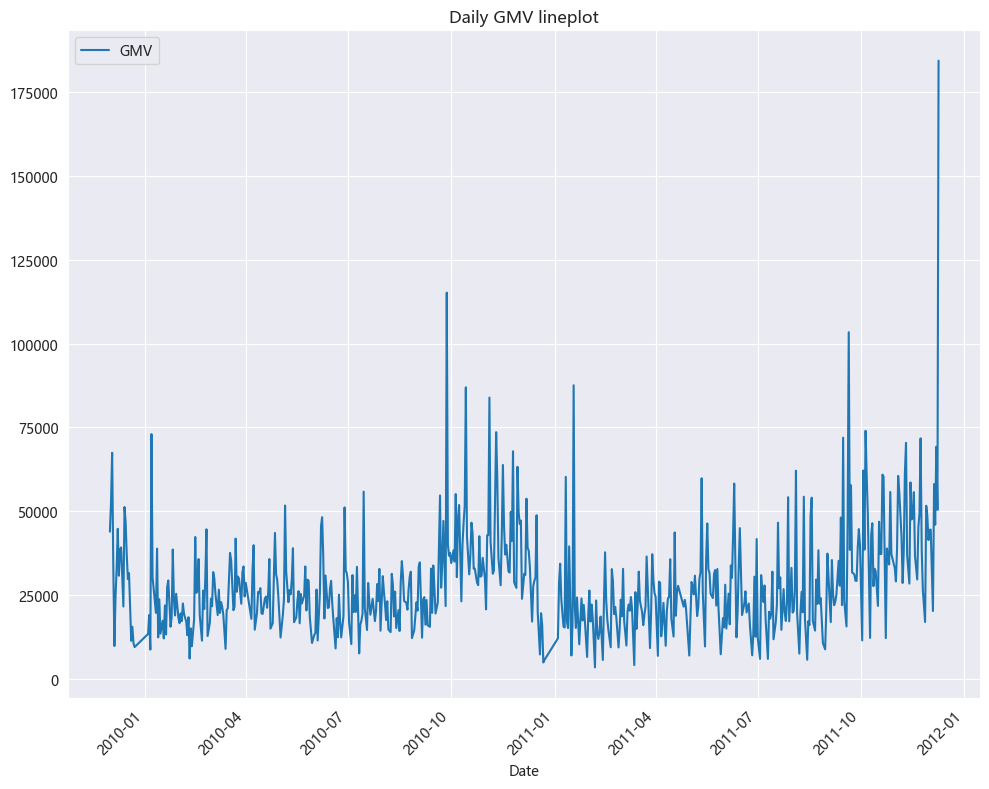

In [12]:
df_GMV_day.plot(x='Date', y='GMV', kind='line', figsize=(10, 8))
plt.xticks(rotation=45)
plt.title('Daily GMV lineplot')
plt.tight_layout()
plt.show()

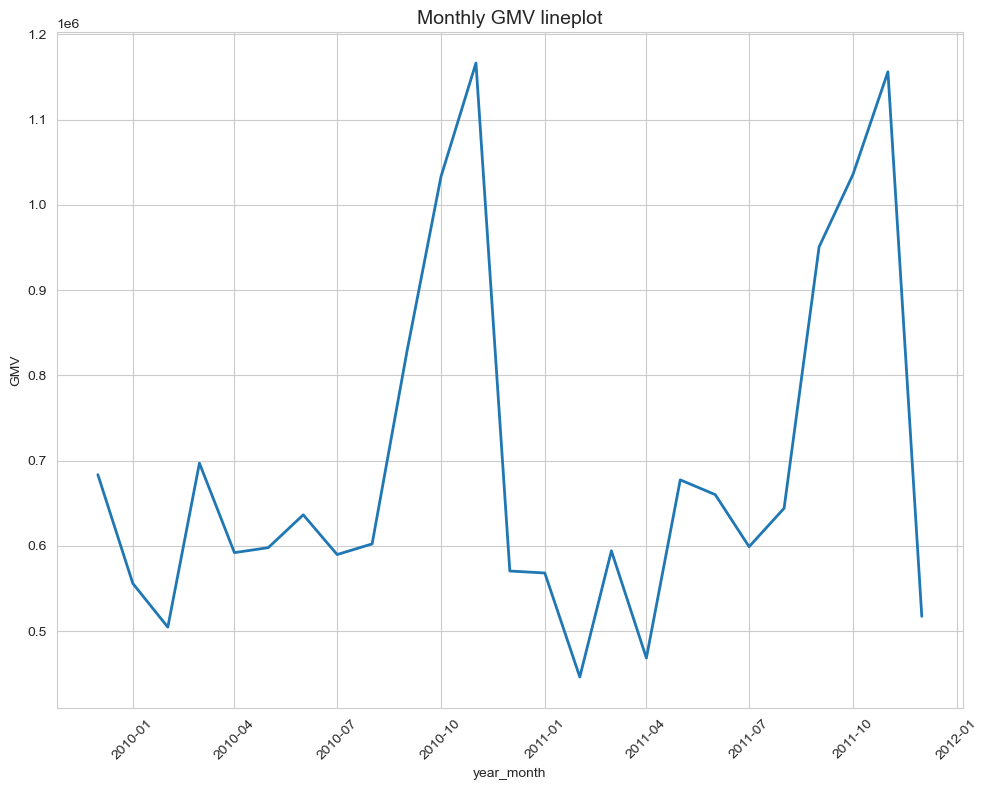

In [15]:

sns.set_style('whitegrid')  # 样式，不覆盖字体
plt.figure(figsize=(10, 8))
sns.lineplot(data=df_GMV_month, x='year_month', y='GMV', markers='o', linewidth=2)
plt.title('Monthly GMV lineplot', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [16]:
df_order_detail

,Invoice,StockCode,Quantity,InvoiceDate,Price,Customer ID,Country,Date,year_month,amount
0,489434,85048,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,2009-12-01,2009-12-01,83.40
1,489434,79323P,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009-12-01,2009-12-01,81.00
2,489434,79323W,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009-12-01,2009-12-01,81.00
3,489434,22041,48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,2009-12-01,2009-12-01,100.80
4,489434,21232,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,2009-12-01,2009-12-01,30.00
...,...,...,...,...,...,...,...,...,...,...
1067366,581587,22899,6,2011-12-09 12:50:00,2.10,12680.0,France,2011-12-09,2011-12-01,12.60
1067367,581587,23254,4,2011-12-09 12:50:00,4.15,12680.0,France,2011-12-09,2011-12-01,16.60
1067368,581587,23255,4,2011-12-09 12:50:00,4.15,12680.0,France,2011-12-09,2011-12-01,16.60
1067369,581587,22138,3,2011-12-09 12:50:00,4.95,12680.0,France,2011-12-09,2011-12-01,14.85


In [17]:
df_products = df_order_detail.groupby(['year_month', 'StockCode']).agg(
    quantity=('Quantity', 'sum'),
    order_count=('Invoice', 'nunique'),
    GMV = ('amount', 'sum')
).reset_index()
df_products['avg_price'] = df_products['GMV'] / df_products['quantity']

In [18]:
df_products.describe()

,year_month,quantity,order_count,GMV,avg_price
count,60591,60591.000000,60591.000000,60591.000000,60591.000000
mean,2010-11-27 05:21:17.476852992,173.523329,12.689426,286.755529,3.353878
min,2009-12-01 00:00:00,1.000000,1.000000,0.001000,0.001000
25%,2010-06-01 00:00:00,9.000000,2.000000,19.800000,0.902000
50%,2010-12-01 00:00:00,41.000000,6.000000,71.400000,1.806180
75%,2011-06-01 00:00:00,157.000000,15.000000,257.000000,3.750000
max,2011-12-01 00:00:00,80995.000000,437.000000,168469.600000,1599.260000
std,NaN,628.247851,19.233223,1053.058948,12.365231


In [19]:
df_products.head()

,year_month,StockCode,quantity,order_count,GMV,avg_price
0,2009-12-01,10002,212,17,180.20,0.850000
1,2009-12-01,10080,4,2,3.40,0.850000
2,2009-12-01,10109,4,1,1.68,0.420000
3,2009-12-01,10120,106,5,22.26,0.210000
4,2009-12-01,10123C,136,9,76.88,0.565294


In [20]:
df_products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60591 entries, 0 to 60590
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   year_month   60591 non-null  datetime64[ns]
 1   StockCode    60591 non-null  object        
 2   quantity     60591 non-null  int64         
 3   order_count  60591 non-null  int64         
 4   GMV          60591 non-null  float64       
 5   avg_price    60591 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(1)
memory usage: 2.8+ MB


In [21]:
df_products_total = df_products.groupby('StockCode').agg(
    quantity=('quantity', 'sum'),
    order_count=('order_count', 'sum'),
    sales = ('GMV', 'sum')
).reset_index()

In [22]:
top10_products = df_products_total.sort_values(['sales', 'quantity'], ascending=[False, False]).head(10)

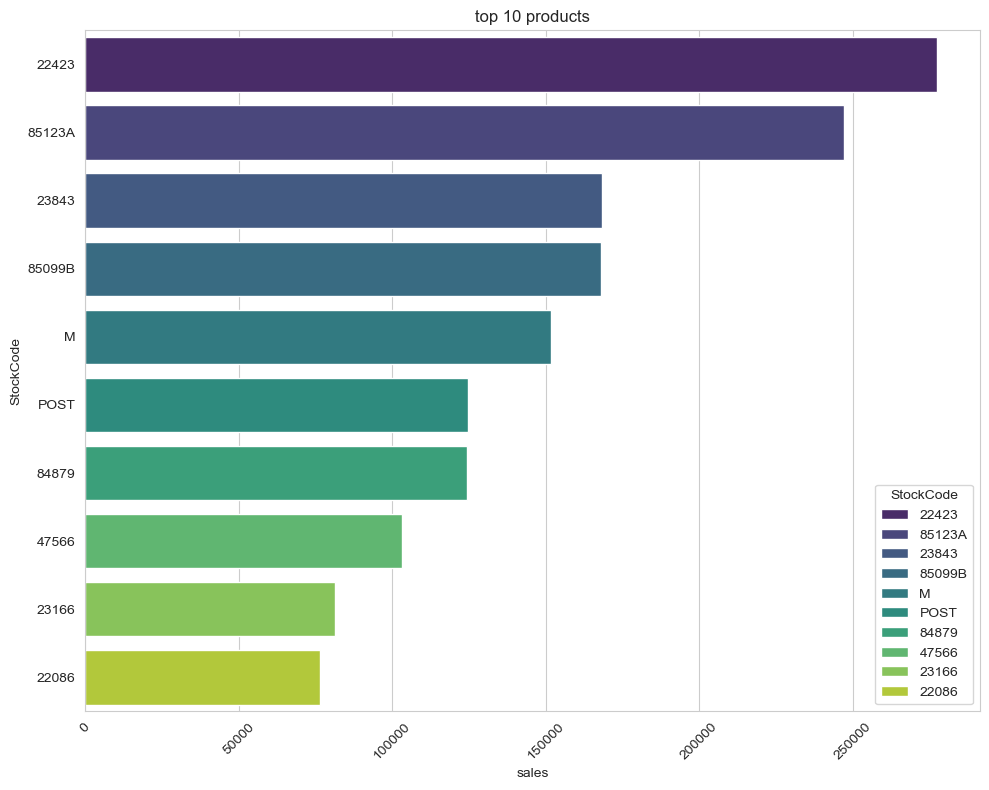

In [23]:
plt.figure(figsize=(10, 8))
sns.barplot(data=top10_products, x='sales', y='StockCode', hue='StockCode', palette='viridis', legend=True)
plt.title('top 10 products')
plt.xticks(rotation=45)
plt.xlabel('sales')
plt.ylabel('StockCode')
plt.tight_layout()
plt.show()

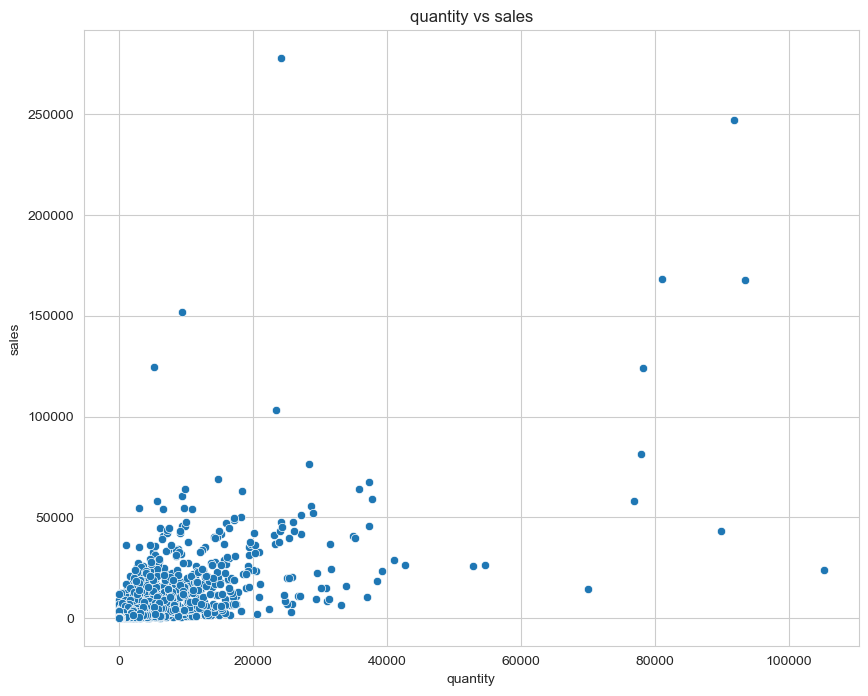

In [24]:
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df_products_total, x='quantity', y='sales')
plt.title('quantity vs sales')
plt.show()

In [25]:
top10_products

,StockCode,quantity,order_count,sales
1609,22423,24124,3317,277656.25
4080,85123A,91814,4895,247203.36
2726,23843,80995,1,168469.60
4058,85099B,93436,3260,167920.64
4625,M,9384,620,151777.67
4627,POST,5235,1803,124648.04
3819,84879,78234,2652,124351.86
3059,47566,23460,2077,103283.38
2324,23166,77916,195,81416.73
1298,22086,28380,1691,76598.18


In [26]:
df_products_total = df_products_total.sort_values('sales', ascending=False).reset_index(drop=True)
total_gmv = df_products_total['sales'].sum()
df_products_total['cum_sales'] = df_products_total['sales'].cumsum()
df_products_total['cum_percent'] = df_products_total['cum_sales']/total_gmv
df_products_total['product_percent'] = (df_products_total.index + 1)/len(df_products_total)

top20_gmv_percent = df_products_total.iloc[int(len(df_products_total)*0.20) -1]['cum_percent']
top20_gmv_percent

np.float64(0.784824560879479)

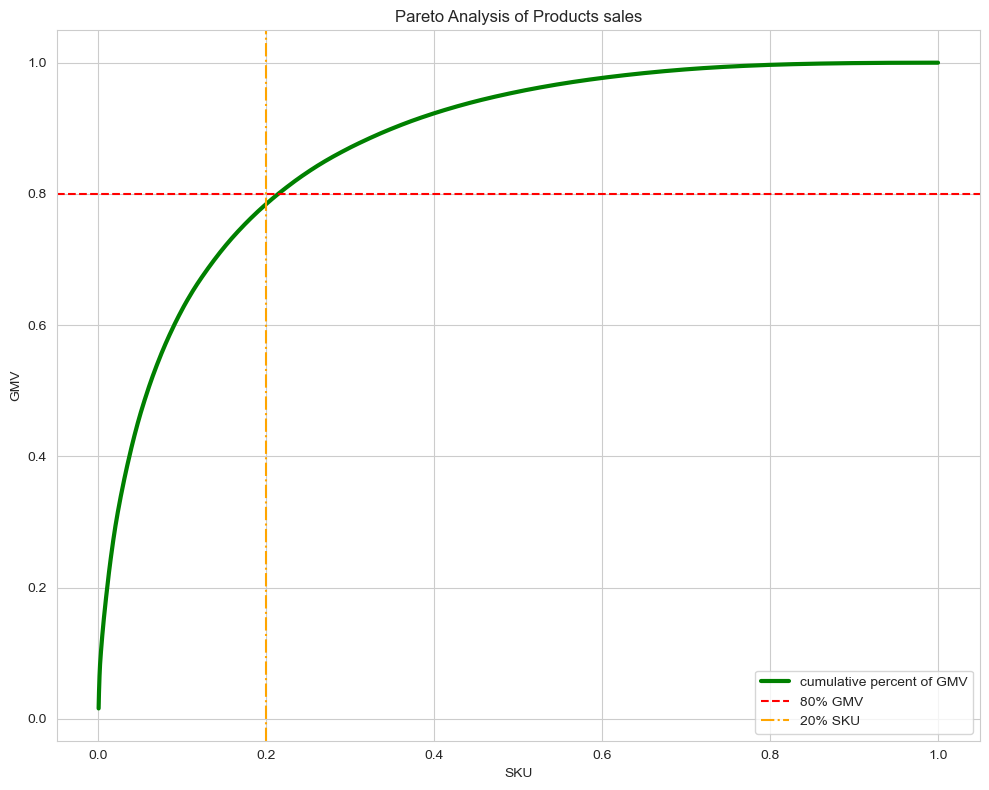

In [27]:
plt.figure(figsize=(10, 8))
sns.lineplot(data=df_products_total, x='product_percent', y='cum_percent', color='green', linewidth=3, label='cumulative percent of GMV')
plt.axhline(0.8, color='red', linestyle='--', label='80% GMV')
plt.axvline(0.2, color='orange', linestyle='-.', label='20% SKU')
plt.xlabel('SKU')
plt.ylabel('GMV')
plt.title('Pareto Analysis of Products sales')
plt.legend()
plt.tight_layout()
plt.show()

In [28]:
def get_top10(month):
    tmp = df_products[df_products['year_month'] == month]
    return tmp.sort_values('GMV', ascending=False).head(10)
months = df_products['year_month'].sort_values().unique()
top10_per_month = [get_top10(m) for m in months]

In [29]:
from matplotlib.animation import FuncAnimation
fig, ax = plt.subplots(figsize=(10,6))
def animate(i):
    ax.clear()
    month_data = top10_per_month[i]
    ax.barh(month_data['StockCode'], month_data['GMV'], color='skyblue')
    ax.set_xlim(0, month_data['GMV'].max()*1.1)
    ax.set_title(f'top10 sales change of products - {months[i]}')
    ax.set_xlabel('GMV')
    ax.set_ylabel('products')
anim = FuncAnimation(fig, animate, frames=len(months),interval=1000)
anim.save('top10_products.gif', writer='pillow', fps=1)
plt.close()

In [30]:
import bar_chart_race as bcr
import matplotlib.pyplot as plt
import warnings

# 字体
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

# 忽略警告
warnings.filterwarnings('ignore')

# pivot
pivot_sales = df_products.pivot_table(
    index='year_month',
    columns='StockCode',
    values='GMV',
    aggfunc='sum'
).fillna(0)


# 动画
bcr.bar_chart_race(
    df=pivot_sales,
    filename='top10_products_race.mp4',
    n_bars=10,
    period_fmt='%Y-%m',
    sort='desc',
    steps_per_period=80,
    period_length=1500,
    interpolate_period=True,
    filter_column_colors=True
)